**<h1>System wspomagania decyzji w wyborze technologii komunikacji czasu rzeczywistego dla aplikacji internetowej na podstawie parametrów scenariusza</h1>**


---



<h3>Link do zbioru danych</h3>

https://drive.google.com/file/d/1KcSJvFQB0R4TZxffi5pKjXOp3PhmqpEr/view?usp=drive_link

<h3>Import bibliotek</h3>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from google.colab import files
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
import ipywidgets as widgets
from IPython.display import display
import csv
import warnings
warnings.filterwarnings("ignore")

Mounted at /content/drive


<h3>Wczytanie danych z pliku .csv</h3>

In [ ]:
csv_path = "/content/drive/MyDrive/results.csv"

# jeśli plik nie istnieje, poproś użytkownika o upload jednorazowy
if not os.path.exists(csv_path):
    from google.colab import files
    print("Plik results.csv nie znaleziony w Google Drive.")
    print("Wgraj go teraz.")
    uploaded = files.upload()
    fname = list(uploaded.keys())[0]
    os.rename(fname, csv_path)
    print("Zapisano jako:", csv_path)

# Wczytanie bazy przypadków z wynikami testów wydajnościowych
raw_df = pd.read_csv(csv_path, sep=';', decimal=',', encoding='utf-8')

<h3>Wyświetlenie danych</h3>

In [ ]:
raw_df

,scenario_id,test_type,technology,users_chatroom,users_server,chatrooms,senders_per_chat_ratio,payload_size_bytes,interval_ms,avg_message_time_ms,min_message_time_ms,max_message_time_ms,throughput,error_rate,cpu_avg,cpu_max,ram_avg,ram_max
0,1,scalability_cold_start,SignalR,1,1,1,1.0,200,10000,47.6,37.0,54.0,NaN,0.00,NaN,NaN,NaN,NaN
1,2,scalability_cold_start,WebSockets,1,1,1,1.0,200,10000,68.8,46.0,88.0,NaN,0.00,NaN,NaN,NaN,NaN
2,3,scalability_cold_start,Polling,1,1,1,1.0,200,10000,174.0,121.0,220.0,NaN,0.00,NaN,NaN,NaN,NaN
3,4,scalability_cold_start,SSE,1,1,1,1.0,200,10000,58.2,37.0,76.0,NaN,0.00,NaN,NaN,NaN,NaN
4,5,scalability_cold_start,SocketIO,1,1,1,1.0,200,10000,107.8,72.0,163.0,NaN,0.00,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
445,446,endurance_chatroom,WebSockets,50,50,1,1.0,10000,200,467.0,NaN,NaN,0.53,0.00,80.6,83.4,94.3,95.9
446,447,endurance_chatroom,Polling,50,50,1,1.0,10000,200,875.0,NaN,NaN,0.17,19.98,93.5,96.9,96.8,98.3
447,448,endurance_chatroom,SSE,50,50,1,1.0,10000,200,743.0,NaN,NaN,0.24,38.91,86.9,92.4,94.8,96.9
448,449,endurance_chatroom,SocketIO,50,50,1,1.0,10000,200,649.0,NaN,NaN,0.34,14.59,88.0,90.6,94.3,96.1


Wyświetlenie liczby wczytanych wierszy oraz kolumn

In [ ]:
print(f'Liczba wierszy: {raw_df.shape[0]}')
print(f'Liczba kolumn: {raw_df.shape[1]}')

Liczba wierszy: 450
Liczba kolumn: 18


Wyświetlenie nazw kolumn (zmiennych)

In [ ]:
print(f'Kolumny: {raw_df.columns}')

Kolumny: Index(['scenario_id', 'test_type', 'technology', 'users_chatroom',
       'users_server', 'chatrooms', 'senders_per_chat_ratio',
       'payload_size_bytes', 'interval_ms', 'avg_message_time_ms',
       'min_message_time_ms', 'max_message_time_ms', 'throughput',
       'error_rate', 'cpu_avg', 'cpu_max', 'ram_avg', 'ram_max'],
      dtype='object')


Opis zmiennych:
- **scenario_id** - unikalny identyfikator scenariusza testowego (przypadku w bazie CBR)
- **test_type** - typ testu wydajnościowego (np. scalability_cold_start, scalability_single_user_min_load, scalability_single_user_many_server_users, scalability_one_sender_many_receivers, scalability_percent_senders, scalability_all_to_all, scalability_multi_room, throughput_chatroom, spike_chatroom, endurance_chatroom)
- **technology** - badana technologia komunikacji real-time (SignalR, WebSockets, SSE, Polling, Socket.IO, gRPC)
- **users_chatroom** - liczba użytkowników w danym pokoju czatu
- **users_server** - całkowita liczba użytkowników obciążających serwer
- **chatrooms** - liczba równocześnie aktywnych pokojów czatu
- **senders_per_chat_ratio** - udział użytkowników wysyłających wiadomości względem wszystkich użytkowników w pokoju (np. 0.1 = 10%)
- **payload_size_bytes** - rozmiar pojedynczej wiadomości w bajtach
- **interval_ms** - interwał czasowy między wysyłaniem kolejnych wiadomości (ms)
- **avg_message_time_ms** - średni czas dostarczenia wiadomości (latency)
- **min_message_time_ms** - minimalny zmierzony czas dostarczenia wiadomości
- **max_message_time_ms** - maksymalny zmierzony czas dostarczenia wiadomości
- **throughput** - przepustowość, liczba obsłużonych/wysłanych wiadomości na sekundę
- **error_rate** - procent błędnych lub nieobsłużonych wiadomości
- **cpu_avg** - średnie wykorzystanie procesora podczas testu
- **cpu_max** - maksymalne wykorzystanie procesora podczas testu
- **ram_avg** - średnie zużycie pamięci RAM podczas testu
- **ram_max** - maksymalne zużycie pamięci RAM podczas testu

Zmienne jakościowe: **test_type**, **technology**

Zmienne ilościowe: **scenario_id, users_chatroom, users_server, chatrooms, senders_per_chat_ratio, payload_size_bytes, interval_ms, avg_message_time_ms, min_message_time_ms, max_message_time_ms, throughput, error_rate, cpu_avg, cpu_max, ram_avg, ram_max**

<h3>Obróbka danych</h3>

Wyświetlenie ogólnych informacji o zbiorze danych

In [ ]:
raw_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 450 entries, 0 to 449
Data columns (total 18 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   scenario_id             450 non-null    int64  
 1   test_type               450 non-null    object 
 2   technology              450 non-null    object 
 3   users_chatroom          450 non-null    int64  
 4   users_server            450 non-null    int64  
 5   chatrooms               450 non-null    int64  
 6   senders_per_chat_ratio  450 non-null    float64
 7   payload_size_bytes      450 non-null    int64  
 8   interval_ms             450 non-null    int64  
 9   avg_message_time_ms     396 non-null    float64
 10  min_message_time_ms     288 non-null    float64
 11  max_message_time_ms     288 non-null    float64
 12  throughput              162 non-null    float64
 13  error_rate              450 non-null    float64
 14  cpu_avg                 108 non-null    fl

Oliczenie liczby brakujących (null) wartości w każdej kolumnie w DataFrame **data**

In [ ]:
raw_df.isnull().sum()

,0
scenario_id,0
test_type,0
technology,0
users_chatroom,0
users_server,0
chatrooms,0
senders_per_chat_ratio,0
payload_size_bytes,0
interval_ms,0
avg_message_time_ms,54


Podstawowe statystyki zbioru danych:

- **count** - liczba niepustych wartości w każdej kolumnie

- **mean** - średnia wartość dla każdej kolumny

- **std** - odchylenie standardowe, czyli miara rozproszenia danych od średniej

- **min** - najmniejsza wartość w każdej kolumnie

- **25%** - dolny kwartyl, czyli wartość, poniżej której znajduje się 25% obserwacji

- **50%** - mediana, czyli wartość środkowa, pomiędzy najmniejszą a największą wartością

- **75%** - górny kwartyl, czyli wartość, poniżej której znajduje się 75% obserwacji

- **max** - największa wartość w każdej kolumnie

In [ ]:
raw_df.describe()

,scenario_id,users_chatroom,users_server,chatrooms,senders_per_chat_ratio,payload_size_bytes,interval_ms,avg_message_time_ms,min_message_time_ms,max_message_time_ms,throughput,error_rate,cpu_avg,cpu_max,ram_avg,ram_max
count,450.000000,450.000000,450.0000,450.000000,450.000000,450.000000,450.000000,396.000000,288.000000,288.000000,162.000000,450.000000,108.000000,108.000000,108.000000,108.000000
mean,225.500000,22.600000,58.0800,1.560000,0.814120,4066.666667,3336.000000,1227.006818,1356.833333,1723.687500,1.530988,3.321756,71.937037,79.730556,82.566667,87.840741
std,130.048068,18.389985,85.4108,1.901166,0.372527,4264.109293,4576.554174,3003.085655,3131.861081,3811.790354,0.843154,9.094828,11.315712,9.060827,10.809177,9.497900
min,1.000000,1.000000,1.0000,1.000000,0.020000,200.000000,200.000000,18.000000,13.000000,23.000000,0.170000,0.000000,43.500000,52.600000,57.600000,64.300000
25%,113.250000,10.000000,10.0000,1.000000,1.000000,200.000000,200.000000,87.850000,64.000000,87.750000,0.932500,0.000000,65.575000,75.475000,73.325000,80.950000
50%,225.500000,10.000000,30.0000,1.000000,1.000000,2000.000000,200.000000,195.300000,99.000000,144.000000,1.345000,0.000000,74.350000,81.550000,86.700000,92.150000
75%,337.750000,30.000000,50.0000,1.000000,1.000000,10000.000000,10000.000000,513.500000,396.500000,618.000000,2.030000,0.000000,80.075000,85.750000,91.150000,95.300000
max,450.000000,50.000000,400.0000,10.000000,1.000000,10000.000000,10000.000000,18063.300000,17547.000000,18989.000000,4.680000,61.390000,93.500000,96.900000,96.800000,98.900000


<h3>Inżynieria cech</h3>

Macierz korelacji dla zmiennych ilościowych

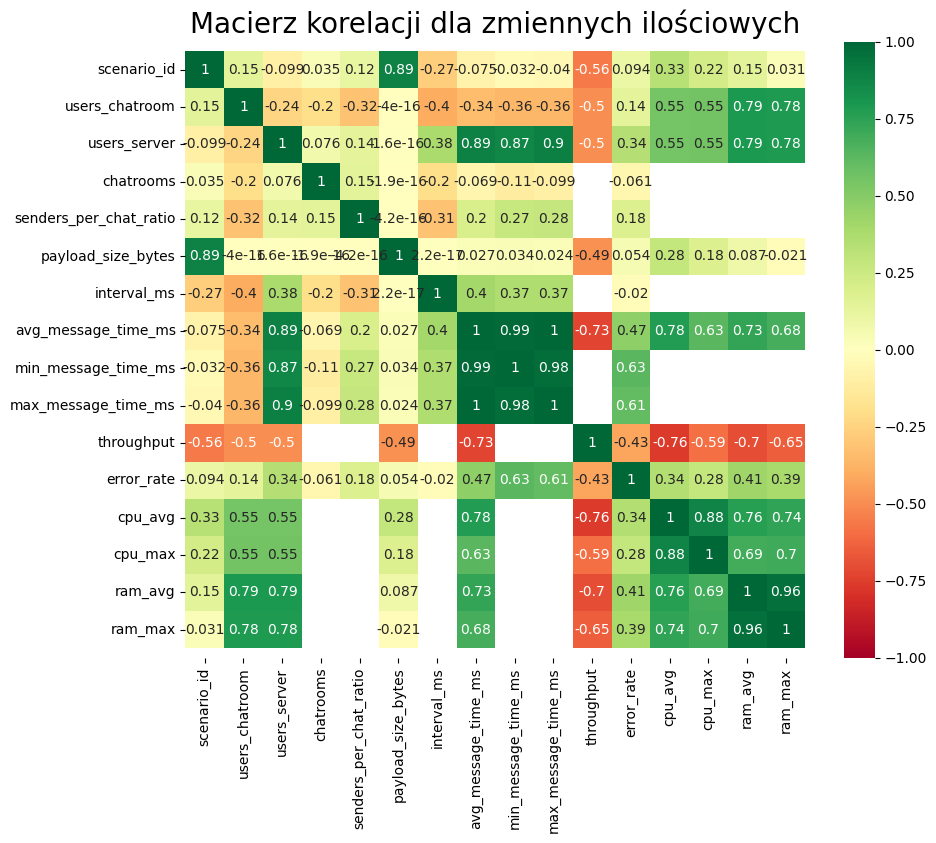

In [ ]:
plt.figure(figsize=(10, 8))
numerical_data = raw_df.select_dtypes(include=[np.number])

ax = sns.heatmap(numerical_data.corr(),
                 xticklabels=numerical_data.corr().columns,
                 yticklabels=numerical_data.corr().columns,
                 cmap='RdYlGn',
                 vmin=-1, vmax=1,
                 annot=True, center=0)

plt.title('Macierz korelacji dla zmiennych ilościowych', fontsize=20)
bottom, top = ax.get_ylim()
ax.set_ylim(bottom + 0.25, top - 0.25)

plt.xticks(fontsize=10)
plt.yticks(fontsize=10)

plt.show()

<h2>Rekomendacja</h2>

<h3>Model rekomendacji CBR + TOPSIS</h3>

W tej pracy zastosowano podejście hybrydowe łączące **Case-Based Reasoning (CBR)** oraz metodę wielokryterialną **TOPSIS**.

Pierwszym etapem działania systemu jest moduł CBR odpowiedzialny za wyszukiwanie przypadków historycznych najbardziej podobnych do zadanego scenariusza testowego. Każdy scenariusz opisywany jest zestawem parametrów, takich jak rodzaj testu, liczba użytkowników, liczba chatroomów, współczynnik nadawców wiadomości, rozmiar wiadomości czy interwał komunikacji.

Podobieństwo między scenariuszami obliczane jest przy użyciu ważonej odległości euklidesowej po wcześniejszej standaryzacji danych numerycznych oraz zakodowaniu cech kategorycznych metodą One-Hot Encoding. W systemie zastosowano dwa tryby doboru wag cech:
- tryb manualny, w którym wagi zostały zdefiniowane ekspercko,
- tryb automatyczny, w którym wagi są dobierane metodą random search osobno dla każdej grupy testów.

Największe znaczenie przypisywane jest rodzajowi testu (test_type), ponieważ determinuje on charakter obciążenia systemu. Wysoką wagę otrzymują również parametry związane z liczbą użytkowników (users_chatroom, users_server), natomiast mniejsze znaczenie mają parametry ruchu sieciowego oraz rozmiar wiadomości.

W trybie automatycznym system wielokrotnie losuje zestawy wag z ustalonych przedziałów wartości, a następnie ocenia ich skuteczność na danych historycznych. Najlepszy zestaw wag wybierany jest na podstawie trafności rekomendacji technologii.

Po odnalezieniu najbardziej podobnych przypadków system agreguje wyniki na poziomie technologii. Wartości metryk wydajnościowych, takich jak czas odpowiedzi, przepustowość, liczba błędów czy zużycie CPU i RAM, wyznaczane są jako średnie ważone z wykorzystaniem poziomu podobieństwa przypadków jako wag. Dzięki temu większy wpływ na końcową ocenę mają scenariusze najbardziej zbliżone do zapytania użytkownika.

Końcowy etap stanowi metoda TOPSIS, która tworzy ranking technologii na podstawie wielu kryteriów jednocześnie. Algorytm wyznacza rozwiązanie idealne (najlepsze wartości metryk) oraz anty-idealne (najgorsze wartości metryk), a następnie oblicza odległość każdej technologii od obu tych punktów.

W systemie zastosowano dwa sposoby wyznaczania wag kryteriów TOPSIS:
- w trybie manualnym wagi definiowane są ekspercko i zależą od rodzaju testu,
- w trybie automatycznym wykorzystywana jest metoda entropii informacyjnej, która automatycznie wyznacza znaczenie poszczególnych metryk na podstawie ich zmienności w danych.

Dla testów przepustowości największą wagę otrzymuje metryka throughput, natomiast dla testów skalowalności dominujące znaczenie mają czasy odpowiedzi i liczba błędów. W przypadku testów typu spike oraz endurance większy nacisk kładziony jest dodatkowo na stabilność wykorzystania zasobów CPU i RAM.

Ostatecznie system generuje ranking technologii oraz wskazuje rozwiązanie najbardziej optymalne dla zadanego scenariusza testowego. Dzięki połączeniu CBR i TOPSIS możliwe jest jednoczesne wykorzystanie wiedzy historycznej oraz wielokryterialnej analizy jakości technologii Real-Time.

<h4>Definicja kolumn scenariusza i metryk</h4>



In [ ]:
# Etykieta technologii Real-Time
TECH_COL = "technology"

# Cechy opisujące scenariusz testowy
scenario_candidates = [
    "test_type",
    "users_chatroom",
    "users_server",
    "chatrooms",
    "senders_per_chat_ratio",
    "payload_size_bytes",
    "interval_ms"
]

# Metryki wydajności zbierane w testach
metric_candidates = [
    "avg_message_time_ms",
    "min_message_time_ms",
    "max_message_time_ms",
    "throughput",
    "error_rate",
    "cpu_avg",
    "cpu_max",
    "ram_avg",
    "ram_max",
]

# Bierzemy tylko kolumny, które faktycznie istnieją w CSV
scenario_cols = [c for c in scenario_candidates if c in raw_df.columns]
metric_cols = [c for c in metric_candidates if c in raw_df.columns]

# Kolumna z nazwą technologii jest wymagana
if TECH_COL not in raw_df.columns:
    raise ValueError(f"Brak wymaganej kolumny '{TECH_COL}' w CSV.")

<h4>Przygotowanie danych do analizy</h4>

In [ ]:
# Kopia danych roboczych wykorzystywana przez część CBR
work_df = raw_df.copy()

# Rozpoznanie kolumn kategorycznych i numerycznych przed konwersją typów
initial_categorical_scenario_cols = [c for c in scenario_cols if work_df[c].dtype == "object"]
initial_numeric_scenario_cols = [c for c in scenario_cols if c not in initial_categorical_scenario_cols]

# Konwersja kolumn liczbowych na typ numeryczny
for col in initial_numeric_scenario_cols + metric_cols:
    work_df[col] = pd.to_numeric(work_df[col], errors="coerce")

# Usunięcie rekordów bez przypisanej technologii
work_df = work_df.dropna(subset=[TECH_COL]).reset_index(drop=True)

# Aktualizacja głównej ramki danych
raw_df = work_df

print("Wczytane kolumny scenariusza:", scenario_cols)
print("Wczytane metryki:", metric_cols)
display(raw_df.head())

Wczytane kolumny scenariusza: ['test_type', 'users_chatroom', 'users_server', 'chatrooms', 'senders_per_chat_ratio', 'payload_size_bytes', 'interval_ms']
Wczytane metryki: ['avg_message_time_ms', 'min_message_time_ms', 'max_message_time_ms', 'throughput', 'error_rate', 'cpu_avg', 'cpu_max', 'ram_avg', 'ram_max']


,scenario_id,test_type,technology,users_chatroom,users_server,chatrooms,senders_per_chat_ratio,payload_size_bytes,interval_ms,avg_message_time_ms,min_message_time_ms,max_message_time_ms,throughput,error_rate,cpu_avg,cpu_max,ram_avg,ram_max
0,1,scalability_cold_start,SignalR,1,1,1,1.0,200,10000,47.6,37.0,54.0,NaN,0.0,NaN,NaN,NaN,NaN
1,2,scalability_cold_start,WebSockets,1,1,1,1.0,200,10000,68.8,46.0,88.0,NaN,0.0,NaN,NaN,NaN,NaN
2,3,scalability_cold_start,Polling,1,1,1,1.0,200,10000,174.0,121.0,220.0,NaN,0.0,NaN,NaN,NaN,NaN
3,4,scalability_cold_start,SSE,1,1,1,1.0,200,10000,58.2,37.0,76.0,NaN,0.0,NaN,NaN,NaN,NaN
4,5,scalability_cold_start,SocketIO,1,1,1,1.0,200,10000,107.8,72.0,163.0,NaN,0.0,NaN,NaN,NaN,NaN


<h4>Preprocessing danych do etapu CBR</h4>

In [ ]:
# Podział cech scenariusza na kategoryczne i numeryczne
categorical_cols = [c for c in scenario_cols if raw_df[c].dtype == "object"]
numeric_cols = [c for c in scenario_cols if c not in categorical_cols]

# Domyślne wartości dla brakujących danych wejściowych
scenario_defaults = {}
for col in scenario_cols:
    if col in categorical_cols:
        mode = raw_df[col].dropna().mode()
        scenario_defaults[col] = mode.iloc[0] if len(mode) else "unknown"
    else:
        scenario_defaults[col] = float(raw_df[col].median())

# OneHotEncoder w wersji zgodnej z różnymi wersjami scikit-learn
try:
    ohe = OneHotEncoder(handle_unknown="ignore", sparse_output=False)
except TypeError:
    ohe = OneHotEncoder(handle_unknown="ignore", sparse=False)

# Transformacja: standaryzacja cech liczbowych + kodowanie kategorycznych
preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_cols),
        ("cat", ohe, categorical_cols),
    ],
    remainder="drop",
    verbose_feature_names_out=False
)

# Zamiana scenariuszy na wektor cech liczbowych
X = preprocessor.fit_transform(raw_df[scenario_cols])
feature_names = preprocessor.get_feature_names_out()
X_df = pd.DataFrame(X, columns=feature_names)

<h4>Grupowanie typów testów</h4>

In [ ]:
def normalize_test_group(test_type):
    tt = str(test_type).lower()

    if tt.startswith("scalability_"):
        return "scalability"
    if "throughput_chatroom" in tt:
        return "throughput"
    if "spike_chatroom" in tt:
        return "spike"
    if "endurance_chatroom" in tt:
        return "endurance"
    return "other"


# Pomocnicza kolumna do strojenia osobno dla grup testów
raw_df["test_group"] = raw_df["test_type"].apply(normalize_test_group)
work_df["test_group"] = work_df["test_type"].apply(normalize_test_group)

<h4>Wagi cech dla miary podobieństwa: wersja manualna + automatyczna</h4>

In [ ]:
# Zakresy wag dla automatycznego strojenia
FEATURE_GROUP_BOUNDS = {
    "test_type": (1.5, 4.0),
    "users": (1.2, 3.0),
    "chatrooms": (1.0, 2.6),
    "traffic": (1.0, 2.4),
    "payload": (1.0, 2.0),
}

# Cache dla wag automatycznych
AUTO_CBR_CACHE = {}      # klucz: test_group
AUTO_TOPSIS_CACHE = {}   # klucz: test_group

def build_feature_weights_manual(feature_names):
    weights = np.ones(len(feature_names), dtype=float)

    for i, name in enumerate(feature_names):
        n = name.lower()

        if n.startswith("test_type"):
            weights[i] = 2.4
        elif n in ["users_chatroom", "users_server"]:
            weights[i] = 1.8
        elif n == "chatrooms":
            weights[i] = 1.6
        elif n in ["senders_per_chat_ratio", "interval_ms", "payload_size_bytes"]:
            weights[i] = 1.5
        else:
            weights[i] = 1.0

    return weights

def build_feature_weights_from_groups(feature_names, group_weights):
    weights = np.ones(len(feature_names), dtype=float)

    for i, name in enumerate(feature_names):
        n = name.lower()

        if n.startswith("test_type"):
            weights[i] = group_weights["test_type"]
        elif n in ["users_chatroom", "users_server"]:
            weights[i] = group_weights["users"]
        elif n == "chatrooms":
            weights[i] = group_weights["chatrooms"]
        elif n in ["senders_per_chat_ratio", "interval_ms"]:
            weights[i] = group_weights["traffic"]
        elif n == "payload_size_bytes":
            weights[i] = group_weights["payload"]
        else:
            weights[i] = 1.0

    return weights

def sample_group_weights(rng):
    return {
        "test_type": rng.uniform(*FEATURE_GROUP_BOUNDS["test_type"]),
        "users": rng.uniform(*FEATURE_GROUP_BOUNDS["users"]),
        "chatrooms": rng.uniform(*FEATURE_GROUP_BOUNDS["chatrooms"]),
        "traffic": rng.uniform(*FEATURE_GROUP_BOUNDS["traffic"]),
        "payload": rng.uniform(*FEATURE_GROUP_BOUNDS["payload"]),
    }

feature_weights_manual = build_feature_weights_manual(feature_names)

<h4>Funkcje CBR - tworzenie zapytania i liczenie podobieństwa</h4>

In [ ]:
def make_query_df(query_dict):
    row = {}
    for col in scenario_cols:
        row[col] = query_dict.get(col, scenario_defaults[col])
    return pd.DataFrame([row])

def compute_similarities(query_df, feature_weights):
    q = preprocessor.transform(query_df)
    diff = (X - q) * feature_weights
    dist = np.sqrt(np.sum(diff ** 2, axis=1))
    sim = 1.0 / (1.0 + dist)
    return sim

def get_similar_cases(query_dict, k=30, feature_weights=None, exclude_idx=None):
    if feature_weights is None:
        feature_weights = feature_weights_manual

    query_df = make_query_df(query_dict)
    similarities = compute_similarities(query_df, feature_weights)

    tmp = work_df.copy()
    tmp["similarity"] = similarities

    if exclude_idx is not None:
        tmp = tmp.drop(index=exclude_idx, errors="ignore")

    tmp = tmp.sort_values("similarity", ascending=False).reset_index(drop=True)

    tech_count = tmp[TECH_COL].nunique()
    top_k = min(max(k, tech_count * 5), len(tmp))
    selected = tmp.head(top_k)

    if selected[TECH_COL].nunique() < tech_count:
        selected = tmp.copy()

    return selected, query_df

<h4>Agregacja przypadków podobnych po technologii</h4>

In [ ]:
def aggregate_by_technology(similar_cases):
    rows = []
    for tech, group in similar_cases.groupby(TECH_COL):
        w = group["similarity"].to_numpy(dtype=float)
        w_sum = w.sum()

        if w_sum == 0:
            w = np.ones(len(group), dtype=float) / len(group)
        else:
            w = w / w_sum

        row = {
            TECH_COL: tech,
            "support_cases": len(group),
            "avg_similarity": group["similarity"].mean()
        }

        for col in metric_cols:
            vals = pd.to_numeric(group[col], errors="coerce")
            if vals.notna().any():
                row[col] = np.average(vals.fillna(vals.median()), weights=w)
            else:
                row[col] = np.nan

        rows.append(row)

    return pd.DataFrame(rows)

<h4>Pobieranie danych dla konkretnej grupy testów</h4>

In [ ]:
def get_group_df(test_type):
    group = normalize_test_group(test_type)

    if group == "scalability":
        return work_df[work_df["test_type"].astype(str).str.startswith("scalability_", na=False)].copy()
    elif group == "throughput":
        return work_df[work_df["test_type"].astype(str).str.contains("throughput_chatroom", na=False)].copy()
    elif group == "spike":
        return work_df[work_df["test_type"].astype(str).str.contains("spike_chatroom", na=False)].copy()
    elif group == "endurance":
        return work_df[work_df["test_type"].astype(str).str.contains("endurance_chatroom", na=False)].copy()

    return work_df.copy()


def get_eval_indices(test_group=None, sample_size=40, random_state=42):
    if test_group is None:
        base_df = work_df
    else:
        base_df = get_group_df(test_group)

    indices = base_df.index.to_numpy()
    if len(indices) == 0:
        return np.array([], dtype=int)

    rng = np.random.default_rng(random_state)

    if sample_size is not None and len(indices) > sample_size:
        indices = rng.choice(indices, size=sample_size, replace=False)

    return np.array(indices, dtype=int)

<h4>Ocena jakości rekomendacji</h4>

In [ ]:
def evaluate_mode_topk_accuracy(
    mode,
    eval_indices,
    top_k=3,
    k=30,
    auto_bundle=None
):
    if len(eval_indices) == 0:
        return 0.0

    correct = 0
    total = 0

    for idx in eval_indices:
        query = work_df.loc[idx, scenario_cols].to_dict()
        true_tech = work_df.loc[idx, TECH_COL]
        test_type = work_df.loc[idx, "test_type"]

        if mode == "manual":
            feature_weights = feature_weights_manual
            topsis_mode = "manual"
        else:
            if auto_bundle is None:
                auto_bundle = get_auto_feature_weights(test_type)

            feature_weights = auto_bundle["feature_weights"]
            topsis_mode = "auto"

        result = recommend_core(
            query,
            k=k,
            feature_weights=feature_weights,
            topsis_mode=topsis_mode,
            exclude_idx=idx
        )

        ranking = result["ranking"][TECH_COL].head(top_k).tolist()

        if true_tech in ranking:
            correct += 1

        total += 1

    return correct / max(total, 1)

def compare_manual_vs_auto_accuracy(test_group=None, sample_size=40, random_state=42, k=30, auto_bundle=None):
    eval_indices = get_eval_indices(
        test_group=test_group,
        sample_size=sample_size,
        random_state=random_state
    )

    manual_acc = evaluate_mode_topk_accuracy("manual", eval_indices, k=k)
    auto_acc = evaluate_mode_topk_accuracy("auto", eval_indices, k=k, auto_bundle=auto_bundle)

    manual_top3 = evaluate_mode_topk_accuracy(
        "manual",
        eval_indices,
        top_k=3,
        k=k
    )

    auto_top3 = evaluate_mode_topk_accuracy(
        "auto",
        eval_indices,
        top_k=3,
        k=k,
        auto_bundle=auto_bundle
    )

    return {
        "manual_accuracy": manual_acc,
        "auto_accuracy": auto_acc,
        "manual_top3_accuracy": manual_top3,
        "auto_top3_accuracy": auto_top3,
        "difference": auto_acc - manual_acc,
        "eval_count": len(eval_indices)
    }

<h4>Główna rekomendacja</h4>

In [ ]:
def recommend_core(query_scenario, k=30, feature_weights=None, topsis_mode="manual", exclude_idx=None):
    if feature_weights is None:
        feature_weights = feature_weights_manual

    test_type = query_scenario.get("test_type", "")
    test_group = normalize_test_group(test_type)

    similar_cases, query_df = get_similar_cases(
        query_scenario,
        k=k,
        feature_weights=feature_weights,
        exclude_idx=exclude_idx
    )

    agg = aggregate_by_technology(similar_cases)

    ranking, topsis_input, used_criteria, used_topsis_weights = topsis_rank(
        agg,
        test_type,
        mode=topsis_mode,
        test_group=test_group
    )

    best = ranking.iloc[0][TECH_COL]

    return {
        "best_technology": best,
        "ranking": ranking,
        "similar_cases": similar_cases,
        "aggregated": agg,
        "query_df": query_df,
        "used_criteria": used_criteria,
        "topsis_weights": used_topsis_weights,
        "feature_weights": feature_weights
    }

def evaluate_recommendation_accuracy(feature_weights, test_group, eval_indices=None, topsis_mode="auto", k=30):
    group_df = get_group_df(test_group)

    if group_df.empty:
        return 0.0

    if eval_indices is None:
        eval_indices = group_df.index.to_numpy()

    correct = 0
    total = 0

    for idx in eval_indices:
        if idx not in work_df.index:
            continue

        query = work_df.loc[idx, scenario_cols].to_dict()
        true_tech = work_df.loc[idx, TECH_COL]

        result = recommend_core(
            query,
            k=k,
            feature_weights=feature_weights,
            topsis_mode=topsis_mode,
            exclude_idx=idx
        )

        if result["best_technology"] == true_tech:
            correct += 1

        total += 1

    return correct / max(total, 1)

<h4>Automatyczne strojenie wag CBR</h4>

In [ ]:
def get_auto_feature_weights(test_type, n_iter=60, eval_size=None, random_state=42, k=30, verbose=True):
    test_group = normalize_test_group(test_type)

    if test_group in AUTO_CBR_CACHE:
        return AUTO_CBR_CACHE[test_group]

    rng = np.random.default_rng(random_state)
    group_df = get_group_df(test_type)

    if group_df.empty:
        bundle = {
            "feature_weights": feature_weights_manual.copy(),
            "score": 0.0,
            "group_weights": None
        }
        AUTO_CBR_CACHE[test_group] = bundle
        return bundle

    indices = group_df.index.to_numpy()

    if eval_size is None:
        eval_size = min(40, len(indices))

    if len(indices) > eval_size:
        eval_indices = rng.choice(indices, size=eval_size, replace=False)
    else:
        eval_indices = indices

    best_score = -1.0
    best_weights = feature_weights_manual.copy()
    best_group_weights = None

    for _ in range(n_iter):
        group_weights = sample_group_weights(rng)
        candidate_weights = build_feature_weights_from_groups(feature_names, group_weights)

        score = evaluate_recommendation_accuracy(
            candidate_weights,
            test_group=test_group,
            eval_indices=eval_indices,
            topsis_mode="auto",
            k=k
        )

        if score > best_score:
            best_score = score
            best_weights = candidate_weights.copy()
            best_group_weights = group_weights.copy()

    bundle = {
        "feature_weights": best_weights,
        "score": best_score,
        "group_weights": best_group_weights
    }

    AUTO_CBR_CACHE[test_group] = bundle

    if verbose:
        print(f"[AUTO CBR | {test_group}] Trafność random search: {best_score:.3f}")
        print(f"[AUTO CBR | {test_group}] Najlepsze wagi grupowe: {best_group_weights}")

    return bundle

<h4>Funkcje TOPSIS - Ranking Technologii Real-Time: wersja manualna + entropy weighting</h4>

In [ ]:
def get_topsis_weights_manual(test_type):
    tt = str(test_type).lower()

    weights = {
        "avg_message_time_ms": 0.25,
        "min_message_time_ms": 0.05,
        "max_message_time_ms": 0.05,
        "throughput": 0.20,
        "error_rate": 0.12,
        "cpu_avg": 0.16,
        "cpu_max": 0.04,
        "ram_avg": 0.10,
        "ram_max": 0.03
    }

    if any(x in tt for x in [
        "scalability_cold_start",
        "scalability_single_user_min_load",
        "scalability_single_user_many_server_users",
        "scalability_one_sender_many_receivers",
        "scalability_percent_senders",
        "scalability_all_to_all",
        "scalability_multi_room"
    ]):
        weights.update({
            "avg_message_time_ms": 0.6,
            "max_message_time_ms": 0.1,
            "min_message_time_ms": 0.1,
            "throughput": 0,
            "error_rate": 0.2,
            "cpu_avg": 0,
            "ram_avg": 0,
            "cpu_max": 0,
            "ram_max": 0
        })

    elif "throughput_chatroom" in tt:
        weights.update({
            "avg_message_time_ms": 0,
            "max_message_time_ms": 0,
            "min_message_time_ms": 0,
            "throughput": 0.8,
            "error_rate": 0.2,
            "cpu_avg": 0,
            "ram_avg": 0,
            "cpu_max": 0,
            "ram_max": 0
        })

    elif "spike_chatroom" in tt:
        weights.update({
            "avg_message_time_ms": 0.15,
            "max_message_time_ms": 0,
            "min_message_time_ms": 0,
            "throughput": 0.11,
            "error_rate": 0.10,
            "cpu_avg": 0.35,
            "cpu_max": 0.07,
            "ram_avg": 0.15,
            "ram_max": 0.05
        })

    elif "endurance_chatroom" in tt:
        weights.update({
            "avg_message_time_ms": 0.15,
            "max_message_time_ms": 0,
            "min_message_time_ms": 0,
            "throughput": 0.11,
            "error_rate": 0.10,
            "cpu_avg": 0.35,
            "cpu_max": 0.07,
            "ram_avg": 0.15,
            "ram_max": 0.05
        })

    return weights

def get_topsis_weights_entropy_for_group(test_group):
    if test_group in AUTO_TOPSIS_CACHE:
        return AUTO_TOPSIS_CACHE[test_group]

    group_df = get_group_df(test_group)
    cols = [c for c in metric_cols if c in group_df.columns]

    if not cols or group_df.empty:
        weights = {}
        AUTO_TOPSIS_CACHE[test_group] = weights
        return weights

    benefit_criteria = {"throughput"}
    eps = 1e-12
    transformed = pd.DataFrame(index=group_df.index)

    for c in cols:
        col = pd.to_numeric(group_df[c], errors="coerce")
        if col.isna().all():
            col = pd.Series(np.zeros(len(group_df)), index=group_df.index)
        else:
            col = col.fillna(col.median())

        x = col.to_numpy(dtype=float)

        if c in benefit_criteria:
            y = x.copy()
        else:
            y = x.max() - x

        y = y - y.min()
        y = np.clip(y, 0.0, None) + eps
        transformed[c] = y

    Xw = transformed.to_numpy(dtype=float)
    col_sums = Xw.sum(axis=0, keepdims=True)
    P = Xw / np.where(col_sums == 0, 1.0, col_sums)

    m, n = P.shape
    if m <= 1:
        w = np.ones(n) / n
    else:
        k = 1.0 / np.log(m)
        entropy = -k * np.sum(np.where(P > 0, P * np.log(P), 0.0), axis=0)
        d = 1.0 - entropy

        if np.allclose(d.sum(), 0):
            w = np.ones(n) / n
        else:
            w = d / d.sum()

    weights = dict(zip(cols, w))
    AUTO_TOPSIS_CACHE[test_group] = weights
    return weights

def topsis_rank(agg_df, test_type, mode="manual", test_group=None):
    if agg_df.empty:
        raise ValueError("Brak danych do TOPSIS.")

    if test_group is None:
        test_group = normalize_test_group(test_type)

    if mode == "manual":
        weights_dict = get_topsis_weights_manual(test_type)
        criteria = [c for c in weights_dict.keys() if c in agg_df.columns]
    else:
        weights_dict = get_topsis_weights_entropy_for_group(test_group)
        criteria = [c for c in weights_dict.keys() if c in agg_df.columns]

    if not criteria:
        raise ValueError("Brak pasujących kryteriów do TOPSIS.")

    work = agg_df[[TECH_COL] + criteria].copy()
    criteria = [c for c in criteria if work[c].notna().any()]
    work = work[[TECH_COL] + criteria].copy()

    for c in criteria:
        work[c] = pd.to_numeric(work[c], errors="coerce")
        if work[c].isna().all():
            work[c] = 0.0
        else:
            work[c] = work[c].fillna(work[c].median())

    # Jeśli auto i entropy zwróciło część kryteriów, filtrujemy do istniejących
    if mode == "auto":
        weights_dict = {c: weights_dict[c] for c in criteria}
    else:
        weights_dict = {c: weights_dict[c] for c in criteria}

    Xv = work[criteria].to_numpy(dtype=float)
    denom = np.sqrt((Xv ** 2).sum(axis=0))
    denom[denom == 0] = 1.0
    R = Xv / denom

    w = np.array([weights_dict[c] for c in criteria], dtype=float)
    if np.isclose(w.sum(), 0):
        w = np.ones(len(criteria), dtype=float) / len(criteria)
    else:
        w = w / w.sum()

    V = R * w

    benefit_criteria = {"throughput"}
    ideal_best = []
    ideal_worst = []

    for i, c in enumerate(criteria):
        col = V[:, i]
        if c in benefit_criteria:
            ideal_best.append(col.max())
            ideal_worst.append(col.min())
        else:
            ideal_best.append(col.min())
            ideal_worst.append(col.max())

    ideal_best = np.array(ideal_best)
    ideal_worst = np.array(ideal_worst)

    d_plus = np.sqrt(((V - ideal_best) ** 2).sum(axis=1))
    d_minus = np.sqrt(((V - ideal_worst) ** 2).sum(axis=1))

    score = d_minus / (d_plus + d_minus + 1e-12)

    result = work[[TECH_COL]].copy()
    result["topsis_score"] = score
    result = result.sort_values("topsis_score", ascending=False).reset_index(drop=True)
    result["rank"] = np.arange(1, len(result) + 1)

    return result, work, criteria, weights_dict

<h4>Walidacja danych wejściowych</h4>

In [ ]:
def validate_recommendation_query(query):
    errors = []

    if int(query["users_chatroom"]) < 1:
        errors.append("users_chatroom musi być >= 1.")
    if int(query["users_server"]) < 1:
        errors.append("users_server musi być >= 1.")
    if int(query["chatrooms"]) < 1:
        errors.append("chatrooms musi być >= 1.")
    if not (0.0 <= float(query["senders_per_chat_ratio"]) <= 1.0):
        errors.append("senders_per_chat_ratio musi być w zakresie 0..1.")
    if int(query["payload_size_bytes"]) <= 0:
        errors.append("payload_size_bytes musi być > 0.")
    if int(query["interval_ms"]) <= 0:
        errors.append("interval_ms musi być > 0.")

    return errors


def validate_add_record_query(record):
    errors = validate_recommendation_query(record)

    if float(record["avg_message_time_ms"]) < 0:
        errors.append("avg_message_time_ms musi być >= 0.")
    if float(record["min_message_time_ms"]) < 0:
        errors.append("min_message_time_ms musi być >= 0.")
    if float(record["max_message_time_ms"]) < 0:
        errors.append("max_message_time_ms musi być >= 0.")
    if float(record["throughput"]) < 0:
        errors.append("throughput musi być >= 0.")
    if not (0.0 <= float(record["error_rate"]) <= 100.0):
        errors.append("error_rate musi być w zakresie 0..100.")
    if not (0.0 <= float(record["cpu_avg"]) <= 100.0):
        errors.append("cpu_avg musi być w zakresie 0..100.")
    if not (0.0 <= float(record["cpu_max"]) <= 100.0):
        errors.append("cpu_max musi być w zakresie 0..100.")
    if not (0.0 <= float(record["ram_avg"]) <= 100.0):
        errors.append("ram_avg musi być w zakresie 0..100.")
    if not (0.0 <= float(record["ram_max"]) <= 100.0):
        errors.append("ram_max musi być w zakresie 0..100.")

    return errors

<h4>Główna funkcja rekomendacji technologii Real-Time</h4>

In [ ]:
def recommend_technology(query_scenario, k=30, show_tables=True, plot=True):
    test_type = query_scenario.get("test_type", "")
    test_group = normalize_test_group(test_type)

    # Rekomendacja manualna
    manual_result = recommend_core(
        query_scenario,
        k=k,
        feature_weights=feature_weights_manual,
        topsis_mode="manual"
    )

    # Rekomendacja automatyczna
    auto_bundle = get_auto_feature_weights(test_type)

    auto_result = recommend_core(
        query_scenario,
        k=k,
        feature_weights=auto_bundle["feature_weights"],
        topsis_mode="auto"
    )

    # Porównanie jakości
    comparison = compare_manual_vs_auto_accuracy(
        test_group=test_group,
        sample_size=min(30, len(get_group_df(test_type))),
        random_state=42,
        k=k,
        auto_bundle=auto_bundle
    )

    if show_tables:

        print("=== SCENARIUSZ WEJŚCIOWY ===")
        display(manual_result["query_df"])

        print("\n=== RANKING TECHNOLOGII — TRYB MANUALNY ===")
        display(manual_result["ranking"])

        print("\n=== RANKING TECHNOLOGII — TRYB AUTOMATYCZNY ===")
        display(auto_result["ranking"])

        print("\n=== PORÓWNANIE JAKOŚCI REKOMENDACJI ===")

        comparison_df = pd.DataFrame([
            {
                "tryb": "manual",
                "top1_accuracy": round(comparison["manual_accuracy"], 3),
                "top3_accuracy": round(comparison["manual_top3_accuracy"], 3),
            },
            {
                "tryb": "auto",
                "top1_accuracy": round(comparison["auto_accuracy"], 3),
                "top3_accuracy": round(comparison["auto_top3_accuracy"], 3),
            }
        ])

        comparison_df["różnica_top1_auto_manual"] = np.nan
        comparison_df.loc[
            comparison_df["tryb"] == "auto",
            "różnica_top1_auto_manual"
        ] = round(comparison["difference"], 3)

        display(comparison_df)

        print(f"\nLiczba przypadków testowych: {comparison['eval_count']}")

        print("\n=== WYNIKI DOKŁADNOŚCI ===")
        print(f"Manual TOP-1 Accuracy: {comparison['manual_accuracy']:.3f}")
        print(f"Manual TOP-3 Accuracy: {comparison['manual_top3_accuracy']:.3f}")

        print(f"\nAuto TOP-1 Accuracy: {comparison['auto_accuracy']:.3f}")
        print(f"Auto TOP-3 Accuracy: {comparison['auto_top3_accuracy']:.3f}")

        print(f"\nRóżnica TOP-1 (auto - manual): {comparison['difference']:+.3f}")

        print("\n=== KRYTERIA TOPSIS ===")
        print("Manual:", manual_result["used_criteria"])
        print("Auto:", auto_result["used_criteria"])

        print("\n=== WAGI TOPSIS ===")
        print("Manual:", manual_result["topsis_weights"])
        print("Auto:", auto_result["topsis_weights"])

        print("\n=== REKOMENDOWANA TECHNOLOGIA ===")
        print(f"Manual: {manual_result['best_technology']}")
        print(f"Auto: {auto_result['best_technology']}")

        print(
            f"\nTrafność automatycznego strojenia CBR "
            f"dla grupy '{test_group}': "
            f"{auto_bundle['score']:.3f}"
        )

    if plot:

        plt.figure(figsize=(10, 4))
        plt.bar(
            manual_result["ranking"][TECH_COL],
            manual_result["ranking"]["topsis_score"]
        )

        plt.title("Ranking technologii (TOPSIS) — manual")
        plt.ylabel("TOPSIS score")
        plt.xlabel("Technologia")
        plt.xticks(rotation=30, ha="right")
        plt.tight_layout()
        plt.show()

        plt.figure(figsize=(10, 4))
        plt.bar(
            auto_result["ranking"][TECH_COL],
            auto_result["ranking"]["topsis_score"]
        )

        plt.title("Ranking technologii (TOPSIS) — auto")
        plt.ylabel("TOPSIS score")
        plt.xlabel("Technologia")
        plt.xticks(rotation=30, ha="right")
        plt.tight_layout()
        plt.show()

    return {
        "manual": manual_result,
        "auto": auto_result,
        "comparison": comparison
    }

<h4>Dopisywanie nowych rekordów do pliku .csv</h4>



In [ ]:
# Obsługa identyfikatora scenariusza
def get_next_scenario_id(csv_path):
    if not os.path.exists(csv_path):
        return 1

    df_id=pd.read_csv(csv_path,sep=';',encoding='utf-8')

    if "scenario_id" not in df_id.columns:
        return 1

    ids=pd.to_numeric(df_id["scenario_id"],errors="coerce").dropna()

    if len(ids)==0:
        return 1

    return int(ids.max())+1

# Funkcja dopisywania nowego rekordu
def add_new_test_result(
    scenario_id,
    technology,
    test_type,
    users_chatroom,
    users_server,
    chatrooms,
    senders_per_chat_ratio,
    payload_size_bytes,
    interval_ms,
    avg_message_time_ms,
    min_message_time_ms,
    max_message_time_ms,
    throughput,
    error_rate,
    cpu_avg,
    cpu_max,
    ram_avg,
    ram_max,
    csv_path="/content/drive/MyDrive/results.csv"
):
    # Jeden wiersz odpowiada jednemu przypadkowi testowemu
    row=[
        scenario_id,
        test_type,
        technology,
        users_chatroom,
        users_server,
        chatrooms,
        senders_per_chat_ratio,
        payload_size_bytes,
        interval_ms,
        avg_message_time_ms,
        min_message_time_ms,
        max_message_time_ms,
        throughput,
        error_rate,
        cpu_avg,
        cpu_max,
        ram_avg,
        ram_max
    ]

    # Dopisanie rekordu do pliku CSV
    with open(csv_path,'a',newline='',encoding='utf-8') as f:
        writer=csv.writer(f,delimiter=';')
        writer.writerow(row)

    print("Dodano rekord.")

# Formularz do dodawania nowych danych do pliku .csv
def add_data_form():
    scenario_id_val = get_next_scenario_id("/content/drive/MyDrive/results.csv")
    print(f"Nowy scenario_id: {scenario_id_val}")

    style = {'description_width': '220px'}

    # Pola formularza odpowiadające kolumnom w CSV
    technology_widget = widgets.Dropdown(
        options=["SignalR", "WebSockets", "Polling", "SSE", "SocketIO", "gRPC"],
        description="Technologia",
        value="SignalR"
    )
    test_type_widget = widgets.Dropdown(
        options=[
            "scalability_cold_start", "scalability_single_user_min_load",
            "scalability_single_user_many_server_users", "scalability_one_sender_many_receivers",
            "scalability_percent_senders", "scalability_all_to_all",
            "scalability_multi_room", "throughput_chatroom", "spike_chatroom",
            "endurance_chatroom"
        ],
        description="Rodzaj testu",
        value="endurance_chatroom"
    )
    users_chatroom_widget = widgets.BoundedIntText(
        description="Liczba uzytkowników w chatroom\'ie", value=1, min=1, max=10**9, style=style
    )
    users_server_widget = widgets.BoundedIntText(
        description="Liczba uzytkowników na serwerze", value=1, min=1, max=10**9, style=style
    )
    chatrooms_widget = widgets.BoundedIntText(
        description="Liczba chatroom\'ów", value=1, min=1, max=10**9, style=style
    )
    senders_per_chat_ratio_widget = widgets.BoundedFloatText(
        description="Współczynnik wysyłania wiadomości (0.0-1.0)", value=1.0, min=0.0, max=1.0, step=0.01, style=style
    )
    payload_size_bytes_widget = widgets.BoundedIntText(
        description="Rozmiar wiadomości (w bajtach)", value=200, min=1, max=10**9, style=style
    )
    interval_ms_widget = widgets.BoundedIntText(
        description="Interwał czasowy (ms)", value=200, min=1, max=10**9, style=style
    )

    avg_message_time_ms_widget = widgets.BoundedFloatText(
        description="Średni czas wiadomości (ms)", value=0.0, min=0.0, max=1e9, style=style
    )
    min_message_time_ms_widget = widgets.BoundedFloatText(
        description="Minimalny czas wiadomości (ms)", value=0.0, min=0.0, max=1e9, style=style
    )
    max_message_time_ms_widget = widgets.BoundedFloatText(
        description="Maksymalny czas wiadomości (ms)", value=0.0, min=0.0, max=1e9, style=style
    )
    throughput_widget = widgets.BoundedFloatText(
        description="Przepustowość", value=0.0, min=0.0, max=1e9, style=style
    )
    error_rate_widget = widgets.BoundedFloatText(
        description="Procent błędnych wiadomości", value=0.0, min=0.0, max=100.0, step=0.1, style=style
    )
    cpu_avg_widget = widgets.BoundedFloatText(
        description="Średnie zużycie CPU", value=0.0, min=0.0, max=100.0, step=0.1, style=style
    )
    cpu_max_widget = widgets.BoundedFloatText(
        description="Maksymalne zużycie CPU", value=0.0, min=0.0, max=100.0, step=0.1, style=style
    )
    ram_avg_widget = widgets.BoundedFloatText(
        description="Średnie zużycie RAM", value=0.0, min=0.0, max=100.0, step=0.1, style=style
    )
    ram_max_widget = widgets.BoundedFloatText(
        description="Maksymalne zużycie RAM", value=0.0, min=0.0, max=100.0, step=0.1, style=style
    )

    add_button = widgets.Button(description="Dodaj rekord", button_style='success')
    output_form = widgets.Output()

    # Zapis rekordu po kliknięciu przycisku
    def on_add_button_clicked(b):
      with output_form:
          output_form.clear_output()
          try:
              record = {
                  "test_type": test_type_widget.value,
                  "users_chatroom": users_chatroom_widget.value,
                  "users_server": users_server_widget.value,
                  "chatrooms": chatrooms_widget.value,
                  "senders_per_chat_ratio": senders_per_chat_ratio_widget.value,
                  "payload_size_bytes": payload_size_bytes_widget.value,
                  "interval_ms": interval_ms_widget.value,
                  "avg_message_time_ms": avg_message_time_ms_widget.value,
                  "min_message_time_ms": min_message_time_ms_widget.value,
                  "max_message_time_ms": max_message_time_ms_widget.value,
                  "throughput": throughput_widget.value,
                  "error_rate": error_rate_widget.value,
                  "cpu_avg": cpu_avg_widget.value,
                  "cpu_max": cpu_max_widget.value,
                  "ram_avg": ram_avg_widget.value,
                  "ram_max": ram_max_widget.value,
              }

              errors = validate_add_record_query(record)
              if errors:
                  print("Błędne dane wejściowe:")
                  for err in errors:
                      print("-", err)
                  return

              add_new_test_result(
                  scenario_id_val,
                  technology_widget.value,
                  test_type_widget.value,
                  users_chatroom_widget.value,
                  users_server_widget.value,
                  chatrooms_widget.value,
                  senders_per_chat_ratio_widget.value,
                  payload_size_bytes_widget.value,
                  interval_ms_widget.value,
                  avg_message_time_ms_widget.value,
                  min_message_time_ms_widget.value,
                  max_message_time_ms_widget.value,
                  throughput_widget.value,
                  error_rate_widget.value,
                  cpu_avg_widget.value,
                  cpu_max_widget.value,
                  ram_avg_widget.value,
                  ram_max_widget.value
              )
          except Exception as e:
              print(f"Wystąpił błąd: {e}")

    add_button.on_click(on_add_button_clicked)

    return widgets.VBox([
        technology_widget, test_type_widget, users_chatroom_widget, users_server_widget,
        chatrooms_widget, senders_per_chat_ratio_widget, payload_size_bytes_widget,
        interval_ms_widget, avg_message_time_ms_widget, min_message_time_ms_widget,
        max_message_time_ms_widget, throughput_widget, error_rate_widget,
        cpu_avg_widget, cpu_max_widget, ram_avg_widget, ram_max_widget,
        add_button, output_form
    ])

<h4>Formularz do wykonania rekomendacji technologii Real-Time</h4>

In [ ]:
def recommendation_form():
    title = "Rekomendacja"
    button_desc = "Uruchom rekomendację"

    test_type = widgets.Dropdown(
        options=[
            "scalability_cold_start",
            "scalability_single_user_min_load",
            "scalability_single_user_many_server_users",
            "scalability_one_sender_many_receivers",
            "scalability_percent_senders",
            "scalability_all_to_all",
            "scalability_multi_room",
            "throughput_chatroom",
            "spike_chatroom",
            "endurance_chatroom"
        ],
        description='Rodzaj testu'
    )

    style = {'description_width': '210px'}

    users_chatroom = widgets.BoundedIntText(
        value=1, min=1, max=10**9,
        description='Liczba uzytkowników w chatroom\'ie', style=style
    )
    users_server = widgets.BoundedIntText(
        value=1, min=1, max=10**9,
        description='Liczba uzytkowników na serwerze', style=style
    )
    chatrooms = widgets.BoundedIntText(
        value=1, min=1, max=10**9,
        description='Liczba chatroom\'ów', style=style
    )

    senders_ratio = widgets.BoundedFloatText(
        value=1.0, min=0.0, max=1.0, step=0.01,
        description='Współczynnik wysyłania wiadomości (0.0-1.0)', style=style
    )
    payload = widgets.BoundedIntText(
        value=200, min=1, max=10**9,
        description='Rozmiar wiadomości (w bajtach)', style=style
    )
    interval = widgets.BoundedIntText(
        value=200, min=1, max=10**9,
        description='Interwał czasowy (ms)', style=style
    )

    button = widgets.Button(description=button_desc, button_style="success")
    output = widgets.Output()

    def hide(widget):
        widget.layout.display = 'none'

    def show(widget):
        widget.layout.display = ''

    def sync_and_apply_rules(*args):
        tt = test_type.value

        for w in [users_chatroom, users_server, chatrooms, senders_ratio, payload, interval]:
            show(w)

        if tt == "scalability_cold_start":
            users_chatroom.value = 1
            users_server.value = 1
            chatrooms.value = 1
            senders_ratio.value = 1.0
            hide(users_chatroom)
            hide(users_server)
            hide(chatrooms)
            hide(senders_ratio)

        elif tt == "scalability_single_user_min_load":
            users_chatroom.value = 1
            users_server.value = 1
            chatrooms.value = 1
            senders_ratio.value = 1.0
            hide(users_chatroom)
            hide(users_server)
            hide(chatrooms)
            hide(senders_ratio)

        elif tt == "scalability_single_user_many_server_users":
            users_chatroom.value = 1
            chatrooms.value = 1
            senders_ratio.value = 1.0
            hide(users_chatroom)
            hide(chatrooms)
            hide(senders_ratio)
            show(users_server)

        elif tt == "scalability_one_sender_many_receivers":
            chatrooms.value = 1
            senders_ratio.value = 1.0 / max(1, users_chatroom.value)
            users_server.value = max(1, users_chatroom.value)
            hide(chatrooms)
            hide(senders_ratio)
            hide(users_server)
            show(users_chatroom)

        elif tt == "scalability_percent_senders":
            chatrooms.value = 1
            users_server.value = max(1, users_chatroom.value)
            hide(chatrooms)
            hide(users_server)
            show(users_chatroom)
            show(senders_ratio)

        elif tt == "scalability_all_to_all":
            chatrooms.value = 1
            senders_ratio.value = 1.0
            users_server.value = max(1, users_chatroom.value)
            hide(chatrooms)
            hide(senders_ratio)
            hide(users_server)
            show(users_chatroom)

        elif tt == "scalability_multi_room":
            senders_ratio.value = 1.0
            users_server.value = max(1, users_chatroom.value) * max(1, chatrooms.value)
            hide(senders_ratio)
            hide(users_server)
            show(users_chatroom)
            show(chatrooms)

        elif tt == "throughput_chatroom":
            senders_ratio.value = 1.0
            users_server.value = max(1, users_chatroom.value) * max(1, chatrooms.value)
            hide(senders_ratio)
            hide(users_server)
            show(users_chatroom)
            show(chatrooms)

        elif tt == "spike_chatroom":
            senders_ratio.value = 1.0
            users_server.value = max(1, users_chatroom.value) * max(1, chatrooms.value)
            hide(senders_ratio)
            hide(users_server)
            show(users_chatroom)
            show(chatrooms)

        elif tt == "endurance_chatroom":
            senders_ratio.value = 1.0
            users_server.value = max(1, users_chatroom.value) * max(1, chatrooms.value)
            hide(senders_ratio)
            hide(users_server)
            show(users_chatroom)
            show(chatrooms)

    def on_click(b):
        with output:
            output.clear_output(wait=True)
            sync_and_apply_rules()

            query = {
                "test_type": test_type.value,
                "users_chatroom": users_chatroom.value,
                "users_server": users_server.value,
                "chatrooms": chatrooms.value,
                "senders_per_chat_ratio": senders_ratio.value,
                "payload_size_bytes": payload.value,
                "interval_ms": interval.value
            }

            errors = validate_recommendation_query(query)
            if errors:
                print("Błędne dane wejściowe:")
                for err in errors:
                    print("-", err)
                return

            result = recommend_technology(
                query,
                k=30,
                show_tables=True,
                plot=True
            )

    button.on_click(on_click)
    test_type.observe(sync_and_apply_rules, names='value')

    sync_and_apply_rules()

    return widgets.VBox([
        widgets.HTML(f"<h4>{title}</h4>"),
        test_type,
        users_chatroom,
        users_server,
        chatrooms,
        senders_ratio,
        payload,
        interval,
        button,
        output
    ])

<h3>MENU GŁÓWNE SYSTEMU REKOMENDACJI</h3>

In [ ]:
def main_menu():
    btn_add = widgets.Button(description="Dodaj dane", button_style='primary')
    btn_recommend = widgets.Button(description="Rekomendacja", button_style='success')

    ui_output = widgets.Output()

    def add_clicked(b):
        with ui_output:
            ui_output.clear_output(wait=True)
            display(add_data_form())

    def recommend_clicked(b):
        with ui_output:
            ui_output.clear_output(wait=True)
            display(recommendation_form())

    btn_add.on_click(add_clicked)
    btn_recommend.on_click(recommend_clicked)

    display(
        widgets.VBox([
            widgets.HTML("<h3>System rekomendacji technologii Real-Time</h3>"),
            btn_add,
            btn_recommend,
            ui_output
        ])
    )

<h4>Uruchomienie interfejsu graficznego</h4>

In [ ]:
main_menu()